In [87]:
import time
from tqdm import tqdm 
import numpy as np
import matplotlib.pyplot as plt

# Mutli-Armed Bandits

> The most important feature distinguishing reinforcement learning from other types of learning is that it uses training information that evaluates the actions taken rather than instructs by giving correct actions.

## A k-armed Bandit Problem

### Expected and Estimated Action-value 

Each action $(a)$ has a true value:

$$
q_*(a) = \mathbb{E}[R_t \mid A_t = a]
$$

This is the expected reward when action $(a)$ is selected.

Since $(q_*(a))$ is unknown, we estimate it with:

$$
Q_t(a)
$$

Goal:

$$
Q_t(a) \to q_*(a)
$$

If you maintain estimates of the action values, then at any time step there is at least one action whose estimated value is greatest. We call these the greedy actions. When you select one of these actions, we say that you are ***exploiting*** your current knowledge of the values of the actions. If instead you select one of the nongreedy actions, then we say you are ***exploring***, because this enables you to improve your estimate of the nongreedy action’s value.

> Exploitation is the right thing to do to maximize the expected reward on the one step, but exploration may produce the greater total reward in the long run.

### Greedy vs epsilon-greedy

A greedy policy always selects the action with the highest estimated value:

$$
A_t = \arg\max_a Q_t(a)
$$

An epsilon-greedy policy explores with probability $(\epsilon)$:

- with probability $(1 - \epsilon)$: choose the greedy action
- with probability $(\epsilon)$: choose a random action

In [88]:
def argmax_random_tie(values):
    max_value = np.max(values)
    candidates = np.flatnonzero(values == max_value)
    return np.random.choice(candidates)

def greedy_action(Q):
    return argmax_random_tie(Q)

def epsilon_greedy_action(Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q))
    return argmax_random_tie(Q)

## Action-value Methods

### Sample-average action-value estimation

Since the true action value $(q_*(a))$ is unknown, we estimate it by averaging the rewards observed after selecting action $(a)$.

$$
Q_t(a) =
\frac{
\sum_{i=1}^{t-1} R_i \cdot \mathbf{1}_{A_i=a}
}{
\sum_{i=1}^{t-1} \mathbf{1}_{A_i=a}
}
$$

where $(\mathbf{1}_{A_i=a})$ is 1 if action $(a)$ was selected at step $(i)$, and 0 otherwise.

In words:

$$
Q_t(a) =
\frac{
\text{sum of rewards received after choosing } a
}{
\text{number of times action } a \text{ was chosen}
}
$$

If an action has never been selected, we initialize its estimate to a default value, usually 0.

In [89]:
def sample_average(rewards, action):
    r = rewards[action]
    if len(r) == 0:
        return 0.0          # never taken defaults to  0
    return sum(r) / len(r)  # sum rewards / count

## The 10-armed Testbed

We generate 2000 independent bandit problems.

Each bandit has 10 actions.  
The true value of each action is sampled from a normal distribution:

$$
q_*(a) \sim \mathcal{N}(0, 1)
$$

So every row represents one bandit problem, and every column represents the true value of one action.

In [90]:
# 10-armed Testbed
k = 10
n_bandits = 2_000

# True action values q*(a)
# Shape: (2000, 10)
q_true = np.random.normal(loc=0, scale=1, size=(n_bandits, k))

q_true.shape

(2000, 10)

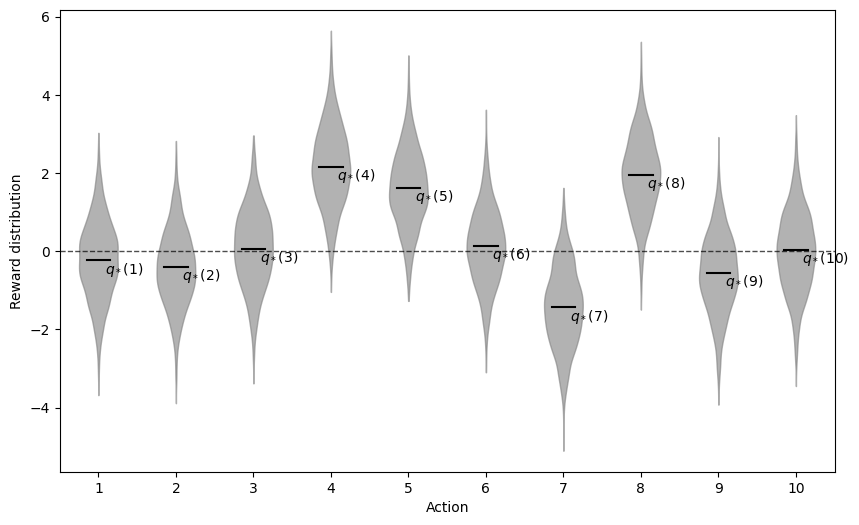

In [91]:
# Reward distributions for a SINGLE bandit's 10 actions.
# q_true holds 2000 bandits; pick one. Each action a -> reward R ~ N(q*(a), 1).
bandit = 0
q_star = q_true[bandit]                                   # 10 distinct true values
samples = np.random.normal(q_star, 1.0, size=(2000, k))   # reward draws per action

fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(
    samples,
    positions=np.arange(1, k + 1),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for pc in parts["bodies"]:
    pc.set_facecolor("gray")
    pc.set_edgecolor("gray")
    pc.set_alpha(0.6)

ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)

for i, q in enumerate(q_star, start=1):
    ax.plot([i - 0.15, i + 0.15], [q, q], color="black", linewidth=1.5)
    ax.text(i + 0.08, q, f"$q_*({i})$", fontsize=10, va="top")

ax.set_xlabel("Action")
ax.set_ylabel("Reward distribution")
ax.set_xticks(np.arange(1, k + 1))
ax.set_xlim(0.5, k + 0.5)

plt.show()

## Greedy vs $\varepsilon$-greedy

We compare how much exploration helps. A purely greedy policy ($\varepsilon=0$) always exploits its current estimates, while $\varepsilon$-greedy policies ($\varepsilon=0.01,\,0.1$) occasionally pick a random action to keep improving them.

We measure two things over time: the average reward earned, and how often each policy selects the truly optimal action. Each policy is run independently on every bandit in the testbed and the results are averaged across runs, so the curves reflect typical behavior rather than a single lucky problem.

In [92]:
def run_epsilon_greedy(q_true, epsilon, steps=1000, seed=0, desc=None):
    """
    Sample-average epsilon-greedy, run per bandit using the
    epsilon_greedy_action selector and sample_average estimator defined above.

    Faithful to the notebook narrative: Q is recomputed each step from the
    full reward history via sample_average (O(steps^2) per bandit -> slow).
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    optimal = np.argmax(q_true, axis=1)          # best action per bandit

    avg_reward = np.zeros(steps)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        Q = np.zeros(k)
        rewards = [[] for _ in range(k)]         # reward history per action

        for t in range(steps):
            if epsilon:
                a = epsilon_greedy_action(Q, epsilon)        # choose action
            else:
                a = greedy_action(Q)

            r = np.random.normal(q_true[b, a], 1.0)      # reward R ~ N(q*(a), 1)
            rewards[a].append(r)
            Q[a] = sample_average(rewards, a)            # update estimate

            avg_reward[t] += r
            pct_optimal[t] += a == optimal[b]

    return avg_reward / n_bandits, pct_optimal / n_bandits


epsilons = [None, 0.01, 0.1]
results = {}
timings = {}  # wall-clock per run, to compare against later methods

for eps in epsilons:
    label = "greedy" if eps is None else f"eps={eps}"
    t0 = time.perf_counter()
    results[eps] = run_epsilon_greedy(q_true, eps, steps=1000, seed=42, desc=label)
    timings[eps] = time.perf_counter() - t0
    print(f"{label:>8}: {timings[eps]:6.1f}s")

  greedy:   47.4s


eps=0.01:   52.5s


 eps=0.1:   49.5s


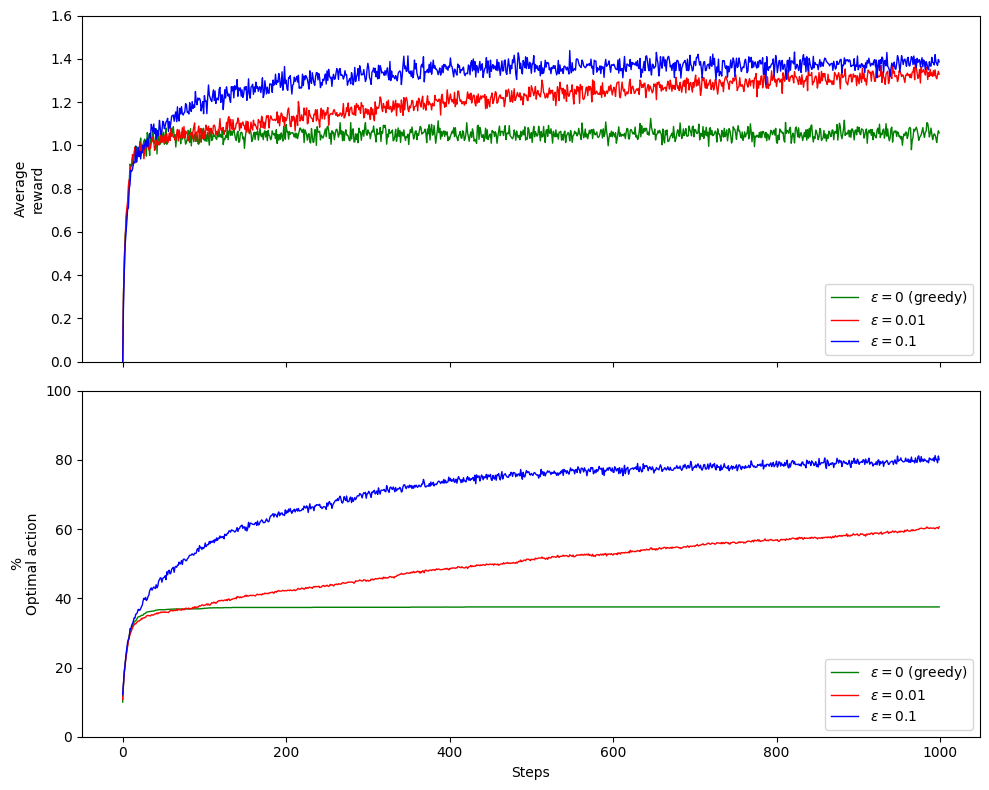

In [93]:
colors = {None: "green", 0.01: "red", 0.1: "blue"}
labels = {None: r"$\varepsilon=0$ (greedy)", 0.01: r"$\varepsilon=0.01$", 0.1: r"$\varepsilon=0.1$"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for eps in epsilons:
    avg_reward, pct_optimal = results[eps]
    ax1.plot(avg_reward, color=colors[eps], linewidth=1, label=labels[eps])
    ax2.plot(pct_optimal * 100, color=colors[eps], linewidth=1, label=labels[eps])

ax1.set_ylabel("Average\nreward")
ax1.set_ylim(0, 1.6)
ax1.legend(loc="lower right")

ax2.set_ylabel("%\nOptimal action")
ax2.set_xlabel("Steps")
ax2.set_ylim(0, 100)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Incremental Implementation

The sample-average estimate can be updated **incrementally**, without storing the full reward history. From

$$
Q_{n+1} = \frac{1}{n}\sum_{i=1}^{n} R_i
$$

a little algebra gives the recursive form

$$
Q_{n+1} = Q_n + \frac{1}{n}\,\bigl[R_n - Q_n\bigr],
$$

i.e. $NewEstimate \leftarrow OldEstimate + StepSize\,[Target - OldEstimate]$.

This is the *simple bandit algorithm*: keep counts $N(a)$ and estimates $Q(a)$, and on each step update only the chosen action with step size $1/N(a)$. It produces the **same** estimates as the explicit average but in $O(1)$ time and memory per step instead of $O(n)$.

Below we rerun the exact same experiment with this update and compare wall-clock time against the non-incremental version (`timings`); no plots, just timing.

In [94]:
def run_epsilon_greedy_incremental(q_true, epsilon, steps=1000, seed=0, desc=None):
    """
    Same epsilon-greedy / sample-average semantics as run_epsilon_greedy,
    but the estimate is updated incrementally:

        N(a) += 1
        Q(a) += (1 / N(a)) * (R - Q(a))

    O(1) time and memory per step instead of recomputing the full average.
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    optimal = np.argmax(q_true, axis=1)

    avg_reward = np.zeros(steps)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        Q = np.zeros(k)
        N = np.zeros(k)

        for t in range(steps):
            if epsilon:
                a = epsilon_greedy_action(Q, epsilon)
            else:
                a = greedy_action(Q)

            r = np.random.normal(q_true[b, a], 1.0)
            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]        # incremental update

            avg_reward[t] += r
            pct_optimal[t] += a == optimal[b]

    return avg_reward / n_bandits, pct_optimal / n_bandits


timings_inc = {}   # incremental wall-clock, to compare against `timings`
for eps in epsilons:
    label = "greedy" if eps is None else f"eps={eps}"
    t0 = time.perf_counter()
    run_epsilon_greedy_incremental(q_true, eps, steps=1000, seed=42, desc=label)
    timings_inc[eps] = time.perf_counter() - t0

# time study: incremental vs non-incremental (sample_average) implementation
print(f"{'method':>8}  {'sample-avg':>11}  {'incremental':>12}  {'speedup':>8}")
for eps in epsilons:
    label = "greedy" if eps is None else f"eps={eps}"
    old, new = timings[eps], timings_inc[eps]
    print(f"{label:>8}  {old:10.1f}s  {new:11.1f}s  {old / new:7.1f}x")

  method   sample-avg   incremental   speedup
  greedy        47.4s         42.2s      1.1x
eps=0.01        52.5s         46.8s      1.1x
 eps=0.1        49.5s         42.6s      1.2x


## Tracking a Nonstationary Problem

For nonstationary problems the reward distributions drift over time, so it makes sense to weight recent rewards more heavily. Replace the $1/n$ step size with a **constant** $\alpha \in (0,1]$:

$$
Q_{n+1} = Q_n + \alpha\,[R_n - Q_n].
$$

Expanding the recursion shows this is an **exponential recency-weighted average** of past rewards and the initial estimate:

$$
Q_{n+1} = (1-\alpha)^n Q_1 + \sum_{i=1}^{n} \alpha\,(1-\alpha)^{\,n-i} R_i.
$$

The weight on $R_i$ decays exponentially with how long ago it was observed; the weights sum to $1$.

### Convergence of the step-size sequence

For a general step-size sequence $\alpha_n(a)$, stochastic-approximation theory guarantees convergence (with probability 1) iff

$$
\sum_{n=1}^{\infty} \alpha_n(a) = \infty
\qquad\text{and}\qquad
\sum_{n=1}^{\infty} \alpha_n^2(a) < \infty.
$$

- The **first** condition makes the steps large enough to overcome initial conditions and random fluctuations.
- The **second** makes them eventually small enough to converge.

| step size | $\sum \alpha_n$ | $\sum \alpha_n^2$ | converges? |
|-----------|-----------------|-------------------|------------|
| sample-average $\alpha_n = 1/n$ | $\infty$ | $<\infty$ | yes |
| constant $\alpha_n = \alpha$ | $\infty$ | $\infty$ | no — keeps tracking |

The constant step size fails the second condition, so the estimate never fully settles — exactly what we want when the target keeps moving.

**Exercise 2.5** compares the two on a nonstationary testbed: $q_*(a)$ all start equal, then take independent random walks ($+\,\mathcal{N}(0,0.01^2)$ each step), with $\varepsilon=0.1$ over $10{,}000$ steps.

In [95]:
def run_nonstationary(step_size=None, epsilon=0.1, steps=10_000, n_bandits=2_000, k=10, seed=0, desc=None):
    """
    Nonstationary 10-armed testbed (Exercise 2.5).

    All true values start equal (q*(a) = 0). On every step each q*(a) takes an
    independent random-walk step ~ N(0, 0.01^2), so the optimal action drifts
    over time. Action selection uses the epsilon_greedy_action selector above.

    step_size=None  -> sample-average update (alpha = 1/N(a))
    step_size=alpha -> constant step size (exponential recency-weighted average)
    """
    np.random.seed(seed)
    avg_reward = np.zeros(steps)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        q_star = np.zeros(k)          # all actions start equal
        Q = np.zeros(k)
        N = np.zeros(k)

        for t in range(steps):
            a = epsilon_greedy_action(Q, epsilon)            # choose action
            r = np.random.normal(q_star[a], 1.0)             # reward R ~ N(q*(a), 1)

            N[a] += 1
            alpha = (1.0 / N[a]) if step_size is None else step_size
            Q[a] += alpha * (r - Q[a])                       # incremental update

            avg_reward[t] += r
            pct_optimal[t] += a == q_star.argmax()           # optimal drifts each step

            q_star += np.random.normal(0.0, 0.01, size=k)    # random walk

    return avg_reward / n_bandits, pct_optimal / n_bandits

In [96]:
results_ns = {}
timings_ns = {}

# 2000 bandits x 10000 steps per method -> slow (minutes); lower n_bandits to speed up
configs = [("sample-avg", None), ("alpha=0.1", 0.1)]
for label, ss in configs:
    t0 = time.perf_counter()
    results_ns[label] = run_nonstationary(step_size=ss, epsilon=0.1, steps=10_000, seed=42, desc=label)
    timings_ns[label] = time.perf_counter() - t0
    print(f"{label:>10}: {timings_ns[label]:6.1f}s")

sample-avg: 1225.7s


 alpha=0.1: 1780.5s


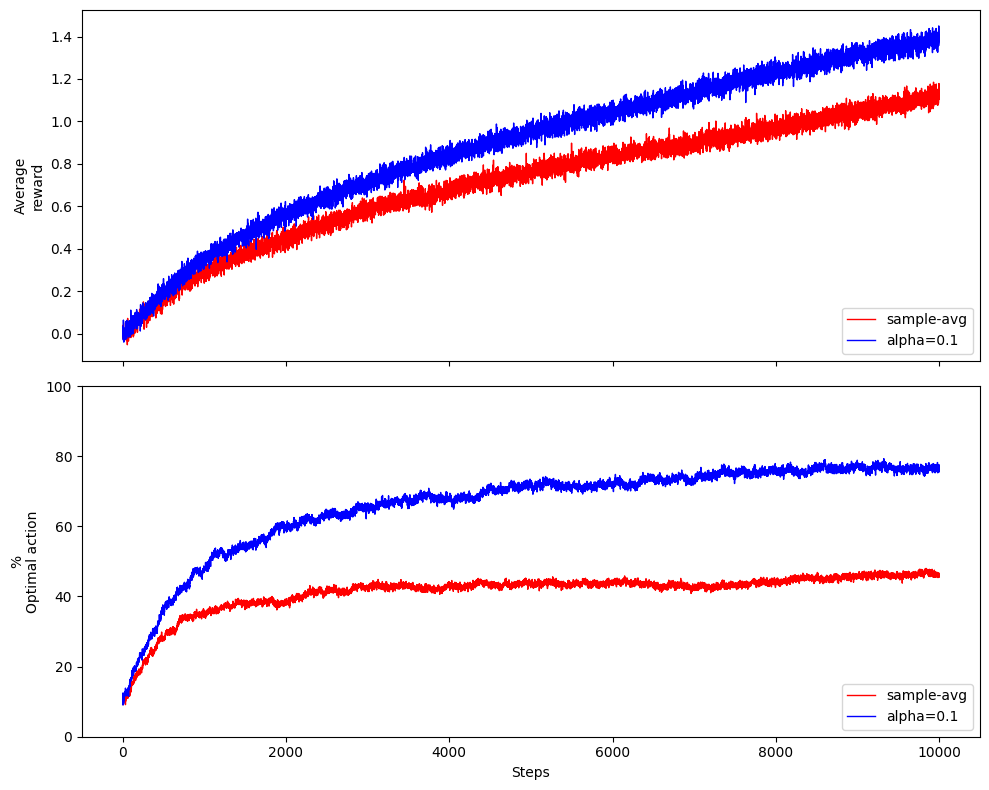

In [97]:
# Exercise 2.5: plots like Figure 2.2 (nonstationary)
colors = {"sample-avg": "red", "alpha=0.1": "blue"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for label, _ in configs:
    avg_reward, pct_optimal = results_ns[label]
    ax1.plot(avg_reward, color=colors[label], linewidth=1, label=label)
    ax2.plot(pct_optimal * 100, color=colors[label], linewidth=1, label=label)

ax1.set_ylabel("Average\nreward")
ax1.legend(loc="lower right")

ax2.set_ylabel("%\nOptimal action")
ax2.set_xlabel("Steps")
ax2.set_ylim(0, 100)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Optimistic Initial Values

All methods so far depend on the initial estimates $Q_1(a)$ — they are **biased** by them. For sample averages the bias disappears once every action has been selected once; for a constant step size $\alpha$ the bias is permanent but decays over time (the $(1-\alpha)^n Q_1$ term).

This bias can be turned into a feature: use the initial values to **encourage exploration**. Set them optimistically high — e.g. $Q_1(a)=+5$ when the true values are $\sim\mathcal{N}(0,1)$. Whatever action is tried first returns a reward smaller than the inflated estimate, so the learner is "disappointed" and switches to other actions; every action gets tried several times before the estimates settle. This drives systematic early exploration **even for a purely greedy policy** ($\varepsilon=0$).

**Figure 2.3** compares optimistic greedy ($Q_1=5,\ \varepsilon=0$) against realistic $\varepsilon$-greedy ($Q_1=0,\ \varepsilon=0.1$), both with constant $\alpha=0.1$ on the stationary testbed. The optimistic method does worse early (it explores heavily) but better afterwards.

Caveat: *optimistic initial values* is a simple trick suited to **stationary** problems only — its drive for exploration is inherently temporary. It does not help when the problem keeps changing (a sudden later change in $q_*$ gets no fresh burst of exploration).

In [98]:
def run_optimistic(q_true, Q_init=0.0, epsilon=0.0, alpha=0.1, steps=1000, seed=0, desc=None):
    """
    Stationary testbed, constant step size alpha, with a chosen initial estimate.

    Q_init=5, epsilon=0   -> optimistic greedy (initial optimism drives exploration)
    Q_init=0, epsilon=0.1 -> realistic epsilon-greedy
    Tracks % optimal action (Figure 2.3).
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    optimal = np.argmax(q_true, axis=1)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        Q = np.full(k, Q_init, dtype=float)      # optimistic / realistic init

        for t in range(steps):
            a = epsilon_greedy_action(Q, epsilon)        # epsilon=0 -> pure greedy
            r = np.random.normal(q_true[b, a], 1.0)
            Q[a] += alpha * (r - Q[a])                   # constant step size

            pct_optimal[t] += a == optimal[b]

    return pct_optimal / n_bandits

In [99]:
runs_opt = {
    "optimistic greedy (Q1=5, eps=0)":      dict(Q_init=5.0, epsilon=0.0),
    "realistic eps-greedy (Q1=0, eps=0.1)": dict(Q_init=0.0, epsilon=0.1),
}

results_opt = {}
for label, cfg in runs_opt.items():
    results_opt[label] = run_optimistic(q_true, alpha=0.1, steps=1000, seed=42, desc=label, **cfg)

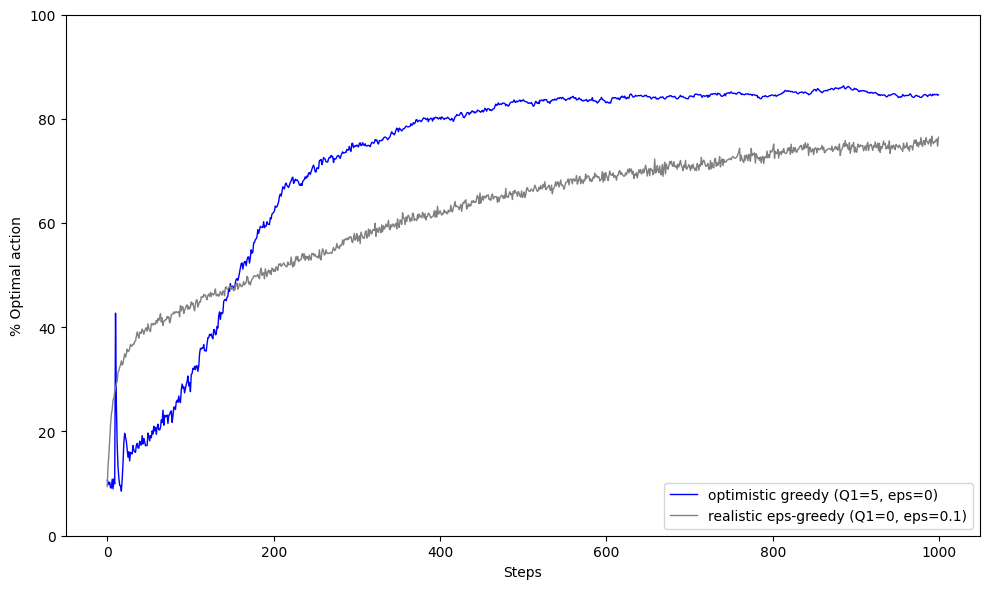

In [100]:
# Figure 2.3: % optimal action
colors = {
    "optimistic greedy (Q1=5, eps=0)": "blue",
    "realistic eps-greedy (Q1=0, eps=0.1)": "gray",
}

fig, ax = plt.subplots(figsize=(10, 6))
for label in runs_opt:
    ax.plot(results_opt[label] * 100, color=colors[label], linewidth=1, label=label)

ax.set_xlabel("Steps")
ax.set_ylabel("% Optimal action")
ax.set_ylim(0, 100)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Exercise 2.7: Unbiased constant-step-size trick.** Process the $n$th reward of an action with step size

$$
\beta_n \doteq \alpha / \bar{o}_n, \qquad \bar{o}_n \doteq \bar{o}_{n-1} + \alpha\,(1-\bar{o}_{n-1}),\quad \bar{o}_0 = 0.
$$

**Solve the trace.** The recursion $\bar{o}_n = \alpha + (1-\alpha)\bar{o}_{n-1}$ with $\bar{o}_0=0$ gives a geometric sum:

$$
\bar{o}_n = \alpha\sum_{i=0}^{n-1}(1-\alpha)^i = 1-(1-\alpha)^n
\qquad\Rightarrow\qquad
\beta_n = \frac{\alpha}{1-(1-\alpha)^n}.
$$

**Unroll the estimate.** With $Q_{n+1} = Q_n + \beta_n[R_n - Q_n] = (1-\beta_n)Q_n + \beta_n R_n$:

$$
Q_{n+1} = \Bigl[\prod_{j=1}^{n}(1-\beta_j)\Bigr]Q_1 \;+\; \sum_{i=1}^{n}\beta_i\Bigl[\prod_{j=i+1}^{n}(1-\beta_j)\Bigr]R_i.
$$

**No initial bias.** The coefficient on $Q_1$ is $\prod_{j=1}^{n}(1-\beta_j)$. But

$$
\beta_1 = \frac{\alpha}{1-(1-\alpha)} = \frac{\alpha}{\alpha} = 1 \quad\Rightarrow\quad (1-\beta_1)=0,
$$

so the entire product is $0$ for every $n\ge 1$: **the weight on $Q_1$ vanishes.** The surviving terms are a weighted average of past rewards whose weights decay exponentially with age (via the $\prod(1-\beta_j)$ factors). Hence $Q_n$ is an exponential recency-weighted average — good for nonstationary problems — *without* the $(1-\alpha)^n Q_1$ bias a plain constant $\alpha$ leaves behind.

In [101]:
def run_unbiased(alpha=0.1, epsilon=0.1, steps=10_000, n_bandits=2_000, k=10, seed=0, desc=None):
    """
    Nonstationary testbed with the unbiased constant-step-size trick (Exercise 2.7):

        o_bar(a) += alpha * (1 - o_bar(a))      # per-action trace, starts at 0
        beta      = alpha / o_bar(a)
        Q(a)     += beta * (R - Q(a))

    On an action's first selection o_bar = alpha, so beta = 1 and the first
    reward fully replaces Q -> no initial bias (the Q1 weight vanishes), while
    later steps recover the exponential recency weighting of a constant alpha.

    Same nonstationary testbed as run_nonstationary (q* start equal, random walk
    ~ N(0, 0.01^2) each step), so results are directly comparable.
    """
    np.random.seed(seed)
    avg_reward = np.zeros(steps)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        q_star = np.zeros(k)
        Q = np.zeros(k)
        o_bar = np.zeros(k)

        for t in range(steps):
            a = epsilon_greedy_action(Q, epsilon)
            r = np.random.normal(q_star[a], 1.0)

            o_bar[a] += alpha * (1 - o_bar[a])           # trace update
            Q[a] += (alpha / o_bar[a]) * (r - Q[a])      # beta = alpha / o_bar

            avg_reward[t] += r
            pct_optimal[t] += a == q_star.argmax()

            q_star += np.random.normal(0.0, 0.01, size=k)    # random walk

    return avg_reward / n_bandits, pct_optimal / n_bandits

In [102]:
# Experimental base that produced results_ns in the nonstationary section
NS_BASE = dict(n_bandits=2_000, steps=10_000, seed=42)

# Base for this comparison. Keep == NS_BASE to REUSE the stored baselines;
# change it (e.g. fewer bandits/steps) for a quick run -> forces a recompute.
ns_kw = NS_BASE
# ns_kw = dict(n_bandits=200, steps=2_000, seed=42)   # fast run (recomputes all 3)

# Reuse whenever the experimental base is identical; otherwise recompute.
same_base = ns_kw == NS_BASE and "results_ns" in globals()

cmp_ns = {
    "sample-avg": results_ns["sample-avg"] if same_base else run_nonstationary(step_size=None, **ns_kw, desc="sample-avg"),
    "alpha=0.1":  results_ns["alpha=0.1"]  if same_base else run_nonstationary(step_size=0.1,  **ns_kw, desc="alpha=0.1"),
    "unbiased":   run_unbiased(alpha=0.1, **ns_kw, desc="unbiased"),
}

print("reused stored baselines" if same_base else "recomputed all methods")

reused stored baselines


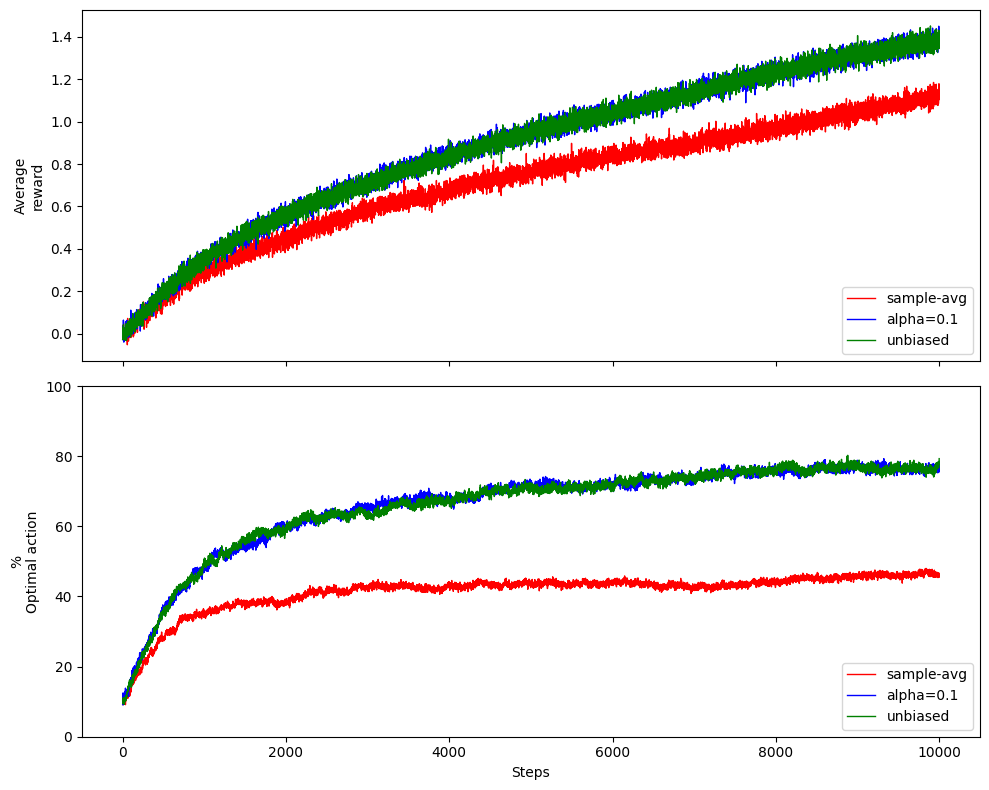

In [103]:
# Exercise 2.7: unbiased trick vs sample-average vs constant-alpha (nonstationary)
colors = {"sample-avg": "red", "alpha=0.1": "blue", "unbiased": "green"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for label, (avg_reward, pct_optimal) in cmp_ns.items():
    ax1.plot(avg_reward, color=colors[label], linewidth=1, label=label)
    ax2.plot(pct_optimal * 100, color=colors[label], linewidth=1, label=label)

ax1.set_ylabel("Average\nreward")
ax1.legend(loc="lower right")

ax2.set_ylabel("%\nOptimal action")
ax2.set_xlabel("Steps")
ax2.set_ylim(0, 100)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Upper-Confidence-Bound Action Selection

Exploration is needed because the action-value estimates are always uncertain. $\varepsilon$-greedy explores **indiscriminately** — when it explores it picks any non-greedy action with equal probability, with no preference for actions that are nearly greedy or especially uncertain. It would be better to favor actions according to their *potential* for actually being optimal, accounting for both how close their estimates are to maximal and the uncertainty in those estimates.

**Upper-Confidence-Bound (UCB)** selection does this:

$$
A_t \doteq \arg\max_a \left[\, Q_t(a) + c\,\sqrt{\frac{\ln t}{N_t(a)}} \,\right].
$$

- $N_t(a)$ = number of times $a$ has been selected before $t$; $c>0$ controls the degree of exploration.
- The square-root term is an **uncertainty bonus**: each selection of $a$ shrinks it ($N_t(a)$ in the denominator grows), while each step that selects some *other* action grows it (numerator $t$ grows, slowly, via $\ln t$).
- $N_t(a)=0$ is treated as maximal, so every action is tried once before the bonus governs choices.

All actions are eventually selected, but those with low estimates or already chosen often are selected with decreasing frequency over time.

**Figure 2.4** compares UCB ($c=2$) against $\varepsilon$-greedy ($\varepsilon=0.1$) on the stationary testbed. UCB generally does better, except in the first $k$ steps when it is still trying each untried action. UCB is harder to extend, though — nonstationary problems and large state spaces (function approximation) make it usually impractical beyond bandits.

In [104]:
def run_ucb(q_true, c=2.0, steps=1000, seed=0, desc=None):
    """
    Upper-Confidence-Bound action selection on the stationary testbed (Figure 2.4):

        A_t = argmax_a [ Q(a) + c * sqrt( ln t / N(a) ) ]

    The square-root term is an uncertainty bonus: it shrinks each time a is
    selected (N(a) grows) and grows for unselected actions (t grows). c > 0
    sets the confidence level. Actions with N(a)=0 are treated as maximal, so
    every action is tried once before the bonus takes over. Sample-average
    (incremental) value updates.
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    avg_reward = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        Q = np.zeros(k)
        N = np.zeros(k)

        for t in range(1, steps + 1):
            untried = np.flatnonzero(N == 0)
            if len(untried):
                a = np.random.choice(untried)                  # try each action once first
            else:
                ucb = Q + c * np.sqrt(np.log(t) / N)
                a = argmax_random_tie(ucb)

            r = np.random.normal(q_true[b, a], 1.0)
            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]                          # incremental sample-average

            avg_reward[t - 1] += r

    return avg_reward / n_bandits

In [105]:
avg_reward_ucb = run_ucb(q_true, c=2.0, steps=1000, seed=42, desc="UCB c=2")
# epsilon-greedy eps=0.1 baseline reused from results[0.1] (greedy vs eps-greedy section)

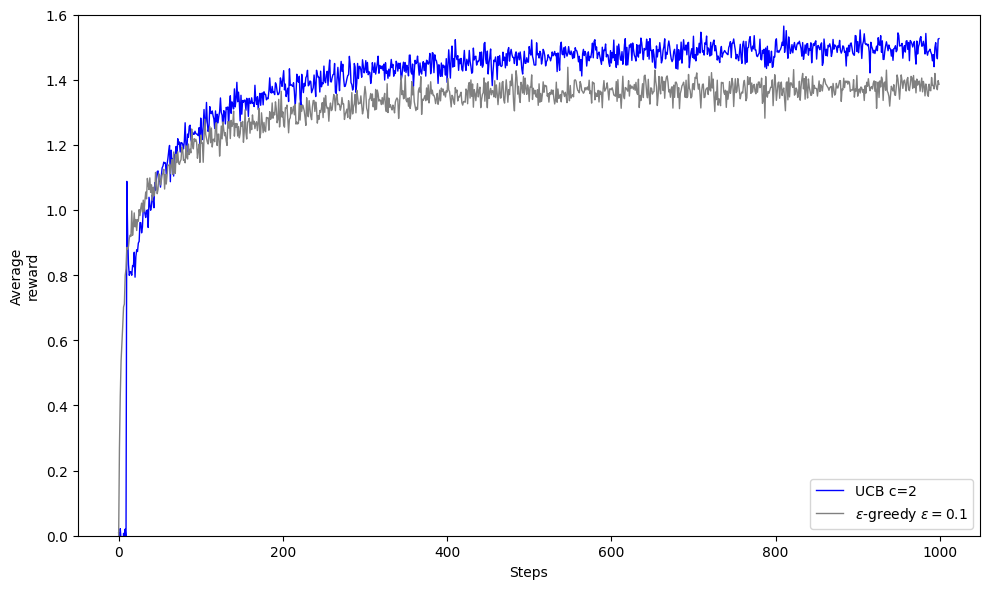

In [106]:
# Figure 2.4: average reward, UCB vs epsilon-greedy
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(avg_reward_ucb, color="blue", linewidth=1, label="UCB c=2")
ax.plot(results[0.1][0], color="gray", linewidth=1, label=r"$\varepsilon$-greedy $\varepsilon=0.1$")

ax.set_xlabel("Steps")
ax.set_ylabel("Average\nreward")
ax.set_ylim(0, 1.6)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Gradient Bandit Algorithms 

So far we estimated action *values* and used them to select actions. An alternative is to learn a numerical **preference** $H_t(a)$ for each action — with no interpretation as a reward. Only *relative* preferences matter; adding a constant to all of them changes nothing. Actions are chosen from a **soft-max** (Gibbs/Boltzmann) distribution:

$$
\Pr\{A_t = a\} \doteq \frac{e^{H_t(a)}}{\sum_{b=1}^{k} e^{H_t(b)}} \doteq \pi_t(a).
$$

Initially all preferences are equal ($H_1(a)=0$), so every action is equally likely.

Preferences are updated by **stochastic gradient ascent**. After selecting $A_t$ and receiving $R_t$:

$$
\begin{aligned}
H_{t+1}(A_t) &= H_t(A_t) + \alpha\,(R_t - \bar{R}_t)\,(1 - \pi_t(A_t)),\\
H_{t+1}(a)   &= H_t(a) - \alpha\,(R_t - \bar{R}_t)\,\pi_t(a), \qquad a \ne A_t,
\end{aligned}
$$

where $\bar{R}_t$ is a **baseline** — the average reward so far (computed incrementally). If $R_t > \bar{R}_t$, the probability of the chosen action increases; if below, it decreases; the non-selected actions move the opposite way.

**Figure 2.5** uses a shifted testbed where $q_*(a) \sim \mathcal{N}(+4, 1)$. The baseline is what lets the algorithm cope with this offset: with the baseline ($\bar{R}_t \approx 4$) only *relative* differences drive learning, so it adapts quickly. Without it ($\bar{R}_t = 0$) every reward looks large and positive, which inflates all preferences indiscriminately and degrades performance markedly.

In [107]:
def run_gradient_bandit(q_true, alpha=0.1, baseline=True, steps=1000, seed=0, desc=None):
    """
    Gradient bandit algorithm (Figure 2.5).

    Learns numerical preferences H(a), not value estimates. Actions are drawn
    from the soft-max policy and preferences move by stochastic gradient ascent:

        pi(a)   = softmax(H)
        H(A_t) += alpha * (R - Rbar) * (1 - pi(A_t))
        H(a)   -= alpha * (R - Rbar) * pi(a)            for a != A_t

    Rbar is the reward baseline: the running mean reward up to (not including)
    the current step. baseline=False fixes Rbar=0.
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    optimal = np.argmax(q_true, axis=1)
    pct_optimal = np.zeros(steps)

    for b in tqdm(range(n_bandits), desc=desc, leave=False):
        H = np.zeros(k)
        Rbar = 0.0

        for t in range(1, steps + 1):
            exp_H = np.exp(H - H.max())          # softmax (shift for numerical stability)
            pi = exp_H / exp_H.sum()
            a = np.random.choice(k, p=pi)        # sample action from the policy

            r = np.random.normal(q_true[b, a], 1.0)
            base = Rbar if baseline else 0.0

            one_hot = np.zeros(k)
            one_hot[a] = 1.0
            H += alpha * (r - base) * (one_hot - pi)     # gradient ascent on preferences

            if baseline:
                Rbar += (r - Rbar) / t                   # running mean reward

            pct_optimal[t - 1] += a == optimal[b]

    return pct_optimal / n_bandits

In [108]:
q_shifted = q_true + 4.0   # q*(a) ~ N(+4, 1): shifted testbed to expose the baseline effect

configs_grad = [
    ("alpha=0.1, baseline",    dict(alpha=0.1, baseline=True)),
    ("alpha=0.4, baseline",    dict(alpha=0.4, baseline=True)),
    ("alpha=0.1, no baseline", dict(alpha=0.1, baseline=False)),
    ("alpha=0.4, no baseline", dict(alpha=0.4, baseline=False)),
]

results_grad = {}
for label, cfg in configs_grad:
    results_grad[label] = run_gradient_bandit(q_shifted, steps=1000, seed=42, desc=label, **cfg)

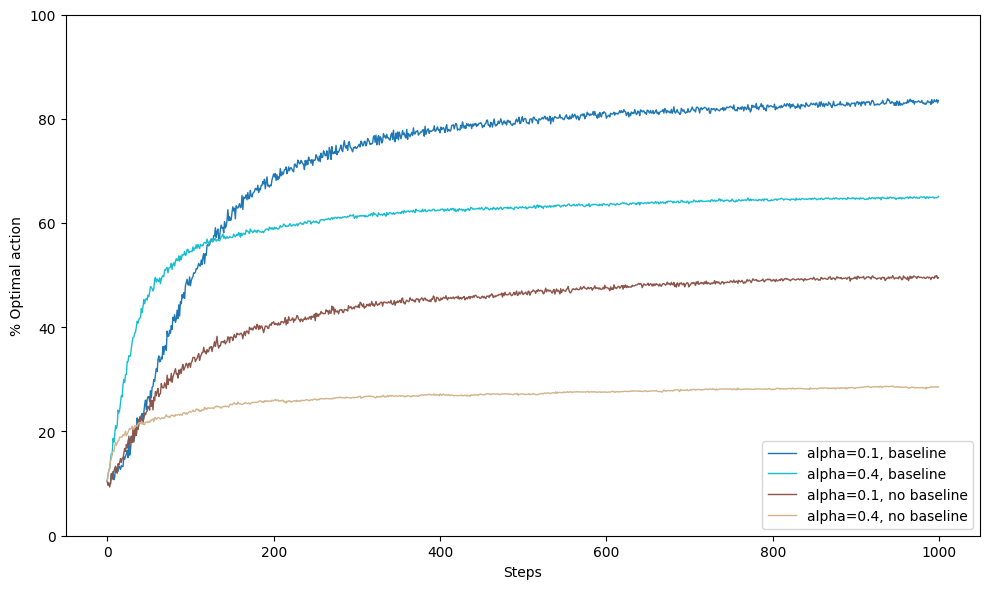

In [109]:
# Figure 2.5: % optimal action, with vs without baseline
styles = {
    "alpha=0.1, baseline":    "tab:blue",
    "alpha=0.4, baseline":    "tab:cyan",
    "alpha=0.1, no baseline": "tab:brown",
    "alpha=0.4, no baseline": "tan",
}

fig, ax = plt.subplots(figsize=(10, 6))
for label, _ in configs_grad:
    ax.plot(results_grad[label] * 100, color=styles[label], linewidth=1, label=label)

ax.set_xlabel("Steps")
ax.set_ylabel("% Optimal action")
ax.set_ylim(0, 100)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Exercise 2.9.** With only two actions the soft-max distribution reduces to the logistic (sigmoid) function. With preferences $H(1), H(2)$:

$$
\pi(1) = \frac{e^{H(1)}}{e^{H(1)} + e^{H(2)}}
       = \frac{1}{1 + e^{-(H(1)-H(2))}}
       = \sigma\bigl(H(1)-H(2)\bigr),
$$

i.e. the probability depends only on the **difference** of the two preferences, passed through the sigmoid $\sigma(x)=1/(1+e^{-x})$ — the same form used in logistic regression and artificial neural networks.

## Associative Search

## Summary

We have seen several simple ways to balance exploration and exploitation:

- **$\varepsilon$-greedy** chooses randomly a small fraction of the time;
- **UCB** chooses deterministically but favors the less-sampled actions via an uncertainty bonus;
- **gradient bandit** learns action preferences and selects via a soft-max policy;
- **optimistic initial values** make a greedy method explore early.

Which is best in general is hard to say. A fair comparison must look at each method's performance *as a function of its own parameter* ($\varepsilon$, $\alpha$, $c$, or $Q_0$). 

**Figure 2.6** is such a **parameter study**: each point is the average reward over the first 1000 steps for one algorithm at one parameter value, with the parameter swept on a log$_2$ scale (factors of two). The curves are characteristically **inverted-U** shaped — every algorithm does best at an intermediate parameter, neither too large nor too small. On this testbed UCB tends to come out on top.

> The single number per run trades the full learning curve for one summary value (area under the curve $\approx$ average reward), which is what makes a clean multi-algorithm comparison possible.

In [110]:
def avg_reward_over_run(algo, param, q_true, steps=1000, seed=0):
    """
    Run one bandit algorithm at a single parameter setting and return the
    average reward over the first `steps` steps (averaged across all bandits).
    This is the single number plotted for each point in Figure 2.6.

    algo / param:
        "eps-greedy" -> epsilon, sample-average
        "ucb"        -> c,       sample-average
        "gradient"   -> alpha,   soft-max preferences with reward baseline
        "optimistic" -> Q0,      greedy (eps=0), constant step size alpha=0.1
    """
    np.random.seed(seed)
    n_bandits, k = q_true.shape
    total = 0.0

    for b in range(n_bandits):
        Q = np.full(k, param if algo == "optimistic" else 0.0, dtype=float)
        N = np.zeros(k)
        H = np.zeros(k)
        Rbar = 0.0

        for t in range(1, steps + 1):
            if algo == "eps-greedy":
                a = epsilon_greedy_action(Q, param)
            elif algo == "optimistic":
                a = greedy_action(Q)                                   # eps = 0
            elif algo == "ucb":
                untried = np.flatnonzero(N == 0)
                a = (np.random.choice(untried) if len(untried)
                     else argmax_random_tie(Q + param * np.sqrt(np.log(t) / N)))
            elif algo == "gradient":
                exp_H = np.exp(H - H.max())
                pi = exp_H / exp_H.sum()
                a = np.random.choice(k, p=pi)

            r = np.random.normal(q_true[b, a], 1.0)
            total += r
            N[a] += 1

            if algo == "gradient":
                one_hot = np.zeros(k)
                one_hot[a] = 1.0
                H += param * (r - Rbar) * (one_hot - pi)
                Rbar += (r - Rbar) / t
            elif algo == "optimistic":
                Q[a] += 0.1 * (r - Q[a])                               # constant alpha = 0.1
            else:                                                      # eps-greedy / ucb
                Q[a] += (r - Q[a]) / N[a]                              # sample average

    return total / (n_bandits * steps)

In [ ]:
N_RUNS = 2_000   # bandits used for the parameter study; lower (e.g. 500) to speed up a lot
q_ps = q_true[:N_RUNS]

# parameter ranges as powers of two (x-axis of Figure 2.6)
param_study = {
    "eps-greedy": [2.0**e for e in range(-7, -1)],   # epsilon: 1/128 .. 1/4
    "gradient":   [2.0**e for e in range(-5,  3)],   # alpha:   1/32  .. 4
    "ucb":        [2.0**e for e in range(-4,  3)],   # c:       1/16  .. 4
    "optimistic": [2.0**e for e in range(-2,  3)],   # Q0:      1/4   .. 4
}

ps_results = {}
for algo, params in param_study.items():
    ps_results[algo] = [
        (p, avg_reward_over_run(algo, p, q_ps, steps=1000, seed=42))
        for p in tqdm(params, desc=algo, leave=False)
    ]

ucb:  14%|█▍        | 1/7 [01:15<07:35, 75.86s/it]        

In [ ]:
# Figure 2.6: parameter study (FINAL plot)
labels = {
    "eps-greedy": (r"$\varepsilon$-greedy",                          "red"),
    "gradient":   ("gradient bandit",                                "green"),
    "ucb":        ("UCB",                                            "blue"),
    "optimistic": (r"greedy with optimistic init $\alpha=0.1$",      "black"),
}

fig, ax = plt.subplots(figsize=(10, 6))
for algo, pts in ps_results.items():
    name, color = labels[algo]
    xs = [np.log2(p) for p, _ in pts]
    ys = [r for _, r in pts]
    ax.plot(xs, ys, color=color, linewidth=1.5, label=name)

ticks = list(range(-7, 3))
tick_labels = ["1/128", "1/64", "1/32", "1/16", "1/8", "1/4", "1/2", "1", "2", "4"]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_xlabel(r"$\varepsilon \quad \alpha \quad c \quad Q_0$")
ax.set_ylabel("Average reward\nover first 1000 steps")
ax.legend(loc="lower center")

plt.tight_layout()
plt.show()